Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Dataset shape: (5572, 2)
Naive Bayes Accuracy: 0.9641
Logistic Regression Accuracy: 0.9668
SVM Accuracy: 0.9865

Best Model: SVM

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



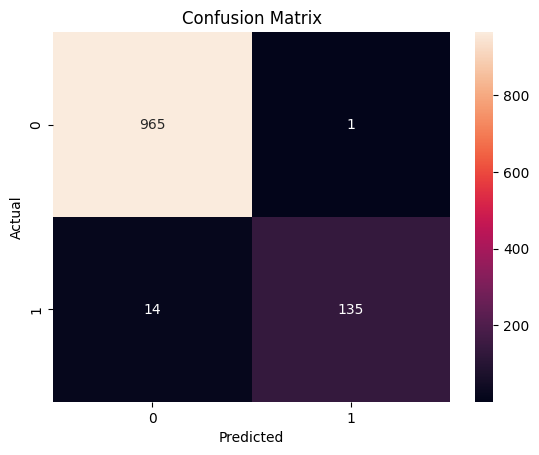

ROC-AUC Score: 0.984819431128156
Message: Congratulations! You've won a free ticket!
Prediction: Spam
--------------------------------------------------
Message: Hey, are we meeting today?
Prediction: Not Spam
--------------------------------------------------

Model saved successfully!


In [1]:
# =========================
# 🚀 ELITE SPAM SMS DETECTION PROJECT
# =========================

# 🔹 Install dependencies (Colab only)
!pip install kagglehub -q

# =========================
# 📥 1. LOAD DATASET
# =========================
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
file_path = os.path.join(path, "spam.csv")

df = pd.read_csv(file_path, encoding='latin-1')

# Keep only required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset shape:", df.shape)
df.head()

# =========================
# 🧹 2. TEXT PREPROCESSING
# =========================
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['message'] = df['message'].apply(clean_text)

# =========================
# ✂️ 3. TRAIN-TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 🔢 4. TF-IDF VECTORIZATION
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# =========================
# 🤖 5. TRAIN MULTIPLE MODELS
# =========================
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

# =========================
# 🏆 6. BEST MODEL SELECTION
# =========================
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# =========================
# 📊 7. DETAILED EVALUATION
# =========================
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test_vec)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# 📉 8. CONFUSION MATRIX
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 📈 9. ROC-AUC SCORE
# =========================
from sklearn.metrics import roc_auc_score

try:
    probs = best_model.decision_function(X_test_vec)
    auc = roc_auc_score(y_test, probs)
    print("ROC-AUC Score:", auc)
except:
    print("ROC-AUC not supported for this model")

# =========================
# 🔍 10. TEST CUSTOM INPUT
# =========================
def predict_message(msg):
    msg = clean_text(msg)
    vec = vectorizer.transform([msg])
    pred = best_model.predict(vec)[0]
    return "Spam" if pred == 1 else "Not Spam"

# Test examples
samples = [
    "Congratulations! You've won a free ticket!",
    "Hey, are we meeting today?"
]

for s in samples:
    print(f"Message: {s}")
    print("Prediction:", predict_message(s))
    print("-"*50)

# =========================
# 💾 11. SAVE MODEL (OPTIONAL)
# =========================
import joblib

joblib.dump(best_model, "spam_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\nModel saved successfully!")